# Preprocesamiento y Regresión logística — Company Bankruptcy Prediction (Taiwan)

En esta sección se preparan los datos para predecir la quiebra empresarial. Primero, se utilizan conjuntos de entrenamiento y prueba obtenidos mediante una partición estratificada, manteniendo una proporción similar de empresas quebradas y solventes.

El preprocesamiento incluye la aplicación de *winsorizing* en los percentiles 1 y 99, utilizando únicamente los límites calculados sobre el conjunto de entrenamiento. Posteriormente, se elimina la variable constante `Net Income Flag` y se estandarizan las variables numéricas mediante `StandardScaler` y  `RobustScaler`, ajustado exclusivamente con los datos de entrenamiento. La variable binaria `Liability-Assets Flag` se conserva sin estandarizar.

A continuación, se entrena una regresión logística con `class_weight='balanced'` para compensar el fuerte desbalance entre clases. El modelo se evalúa mediante *recall*, precisión, F1-score, AUC-ROC, *Average Precision*, matriz de confusión y curvas ROC y Precision-Recall.

Los resultados obtenidos muestran un AUC-ROC de 0.9486 y un *Average Precision* de 0.4270. Para la clase `Quiebra`, el modelo alcanzó un *recall* de 0.89 y una precisión de 0.20, identificando correctamente 39 de las 44 empresas quebradas, aunque generando un número elevado de falsos positivos. Finalmente, se analizan los coeficientes del modelo para identificar las variables asociadas con una mayor o menor probabilidad estimada de quiebra.

## 1. PREPARACIÓN DE DATOS

En esta etapa se preparan los datos para el entrenamiento del modelo. Se separan las variables predictoras de la variable objetivo y se realiza una partición estratificada en conjuntos de entrenamiento y prueba, conservando la proporción de empresas quebradas y no quebradas.

In [1]:
import pickle

with open('train_test_split.pkl', 'rb') as f:
    X_train, X_test, y_train, y_test = pickle.load(f)


print(f"Train: {X_train.shape[0]} empresas, Test: {X_test.shape[0]} empresas")
print(f"Proporción de quiebras en train: {y_train.mean():.2%}")
print(f"Proporción de quiebras en test: {y_test.mean():.2%}")

Train: 5455 empresas, Test: 1364 empresas
Proporción de quiebras en train: 3.23%
Proporción de quiebras en test: 3.23%


In [2]:
# Trabajamos sobre copias, para no dañar los datos originales de X_train / X_test
X_train_prep = X_train.copy()
X_test_prep = X_test.copy()

### 1.1 Winsorizing por percentiles fijos 
Con base en los hallazgos del EDA, donde se identificaron variables con sesgo extremo y una proporción considerable de valores atípicos, se aplicó una técnica de *winsorizing* sobre las 94 variables numéricas del conjunto de datos (en este punto `Net Income Flag` aún no había sido eliminada). Este procedimiento consiste en "topar" los valores extremos de cada variable a un límite predefinido, sin eliminar las observaciones correspondientes, preservando así el tamaño muestral original.

Inicialmente se evaluó la regla del rango intercuartílico (IQR), utilizada previamente en la fase de EDA para la *detección* de valores atípicos. Sin embargo, al aplicarla como criterio de recorte, se observó que generaba una proporción excesivamente alta de valores modificados (42.19%), como consecuencia de la baja dispersión que presentan algunas variables financieras (por ejemplo, `Net Income to Stockholder's Equity`, con una desviación estándar de apenas 0.011 según la Tabla 1). En variables con rangos intercuartílicos muy estrechos, la regla IQR resulta excesivamente sensible y clasifica como atípicos valores que, en la práctica, forman parte del comportamiento normal de la variable.

Por este motivo, se optó por un criterio de recorte basado en percentiles fijos: los valores por debajo del percentil 1 y por encima del percentil 99 de cada variable fueron ajustados a dichos límites. Los percentiles se calcularon exclusivamente sobre el conjunto `train`, y los mismos límites se aplicaron posteriormente sobre `test`, con el fin de evitar fuga de información entre conjuntos.

In [3]:
# Se recorta el 1% inferior y el 1% superior de cada variable, calculado SOLO con train

cols_numericas_winsor = [c for c in X_train.columns if c != 'Liability-Assets Flag']

limites = {}
for col in cols_numericas_winsor:
    p1 = X_train[col].quantile(0.01)
    p99 = X_train[col].quantile(0.99)
    limites[col] = (p1, p99)

X_train_prep = X_train.copy()
X_test_prep = X_test.copy()

for col in cols_numericas_winsor:
    li, ls = limites[col]
    X_train_prep[col] = X_train_prep[col].clip(lower=li, upper=ls)
    X_test_prep[col] = X_test_prep[col].clip(lower=li, upper=ls)  # mismos límites de train

# Verificación
recortes = sum(
    ((X_train[col] < limites[col][0]) | (X_train[col] > limites[col][1])).sum()
    for col in cols_numericas_winsor
)
total_celdas = X_train_prep.shape[0] * len(cols_numericas_winsor)
print(f"Winsorizing aplicado a {len(cols_numericas_winsor)} variables numéricas.")
print(f"Total de valores recortados en train: {recortes} de {total_celdas} celdas ({recortes/total_celdas*100:.2f}%)")

Winsorizing aplicado a 94 variables numéricas.
Total de valores recortados en train: 9648 de 512770 celdas (1.88%)


El procedimiento de winsorizing por percentiles resultó en el recorte de 9.648 celdas de un total de 512.770 (1.88%), una proporción consistente con lo esperado teóricamente, dado que el recorte simétrico en los percentiles 1 y 99 debería afectar, como máximo, alrededor del 2% de las observaciones de cada variable. Este resultado confirma la idoneidad del método de percentiles fijos frente a la regla IQR para este conjunto de datos, en el cual varias variables presentan una dispersión considerablemente reducida.

### 1.2 Eliminar la variable constante

Se eliminará la variable `Net Income Flag`, ya que, como se identificó en la sección anterior, presenta cardinalidad igual a uno. Al ser una variable constante, no aporta capacidad discriminativa al modelo y, por tanto, su eliminación evita incluir información redundante en el proceso de entrenamiento.

In [4]:
# La quitamos de ambos conjuntos, con el mismo criterio.
X_train_prep = X_train_prep.drop(columns=['Net Income Flag'])
X_test_prep = X_test_prep.drop(columns=['Net Income Flag'])
print("Columnas restantes:", X_train_prep.shape[1])

Columnas restantes: 94


### 1.3 Estandarizar las variables numéricas

Las variables tienen escalas muy distintas (algunas van de 0 a 1, otras a miles). Estandarizar las pone a todas en el mismo terreno de juego (media 0, desviación 1), lo cual es clave para modelos sensibles a la magnitud (regresión logística, SVM, PCA).

Tras aplicar `StandardScaler` sobre las variables numéricas de `train` (ajustado únicamente con este conjunto, y luego aplicado a test sin volver a ajustarlo), se verificó que la media resultante fue de 0.0 y la desviación estándar de 1.0001, valores consistentes con lo esperado matemáticamente. La media termina en 0 porque, al restarle a cada valor la media original de su variable, las diferencias positivas y negativas respecto al promedio se cancelan entre sí. La desviación estándar termina en 1 porque, tras centrar los datos, cada valor se divide entre la desviación estándar original de su variable, lo que reescala todas las variables a una misma unidad de dispersión, sin importar si originalmente variaban en un rango pequeño (por ejemplo, un ratio entre 0 y 1) o en uno mucho más amplio (valores del orden de miles). Esta verificación confirma que el proceso de escalado se aplicó correctamente y que las variables quedaron en una escala comparable antes de la etapa de modelado.

Tras utilizar el `StandardScaler` nos dimos cuenta que NO nos convenia por la gran escala y datos atipicos que presenta el data set así que elegimos la opción de `RobustScaler` (En este caso la mediana debe ser 0 y el IQR debe ser 1).

Tras aplicar `RobustScaler` sobre el conjunto completo de variables numéricas, se identificó que, a pesar de tratarse de un escalador robusto frente a valores atípicos, cinco variables continuaban generando valores escalados numéricamente inestables, del orden de decenas de miles a billones. Este comportamiento no se explica por la presencia de outliers convencionales, sino por una inconsistencia de escala de origen en el propio conjunto de datos: como se observa en la tabla siguiente, estas variables conservan valores máximos del orden de cientos de millones (incluso después del recorte por winsorizing) mientras que su rango intercuartílico (IQR) permanece prácticamente nulo. Esta combinación provoca que `RobustScaler`, al dividir por un IQR cercano a cero, amplifique dichos valores a magnitudes extremas, lo que distorsiona por completo el proceso de optimización del modelo.

Es importante señalar que esta anomalía es cualitativamente distinta de la que afecta al resto de variables: mientras que la sexta variable con mayor razón rango/IQR presenta un valor de apenas 100, las cinco variables identificadas superan los cientos de miles de millones una diferencia de varios órdenes de magnitud que evidencia un problema estructural y no una simple cuestión de sesgo o dispersión. Por esta razón, se optó por una estrategia de escalado híbrida: `RobustScaler` se aplicó al resto de variables numéricas, dado que continúa siendo la opción más adecuada frente a los valores atípicos ya documentados en el EDA, mientras que estas cinco variables con escala inconsistente se estandarizaron mediante `StandardScaler`, evitando así la inestabilidad numérica sin sacrificar el desempeño del modelo. 

| Variable | Máximo tras winsorizing | Rango/IQR |
| :--- | :--- | :--- |
| Current Asset Turnover Rate | 9.780.000.000 | 33 billones |
| Fixed Assets Turnover Frequency | 9.610.000.000 | 2,7 billones |
| Interest-bearing debt interest rate | 760.000.000 | 2,3 billones |
| Inventory/Current Liability | 1.540.400.000 | 193.800 millones |
| Long-term Liability to Current Assets | 1.486.000.000 | 166.000 millones |
| *(la 6ª peor)* Degree of Financial Leverage (DFL) | 0,0379 | **100** |

In [5]:
from sklearn.preprocessing import RobustScaler, StandardScaler

# --------------------------------------------------------------------------
# Variables con escala de origen inconsistente: incluso después del
# winsorizing, conservan valores máximos del orden de cientos de millones
# mientras su rango intercuartílico (IQR) permanece casi nulo. Al aplicarles
# RobustScaler, dividir por un IQR ~0 dispara esos valores a magnitudes
# numéricamente inestables (de miles a billones), lo que distorsiona por
# completo el entrenamiento del modelo. Por eso se tratan aparte, con
# StandardScaler, en vez de con el RobustScaler que se usa para el resto.
# --------------------------------------------------------------------------
cols_patologicas = [
    'Interest-bearing debt interest rate',
    'Fixed Assets Turnover Frequency',
    'Inventory/Current Liability',
    'Long-term Liability to Current Assets',
    'Current Asset Turnover Rate',
]

# Identificamos las columnas numéricas (todas menos Liability-Assets Flag, que es categórica)
cols_numericas = [c for c in X_train_prep.columns if c != 'Liability-Assets Flag']
cols_robust = [c for c in cols_numericas if c not in cols_patologicas]

# RobustScaler para la mayoría de variables (robusto a los outliers ya documentados en el EDA)
# .fit_transform() en train: el scaler APRENDE la mediana y el IQR de train,
# y de una vez transforma train con esos valores aprendidos.
robust = RobustScaler()
X_train_prep[cols_robust] = robust.fit_transform(X_train_prep[cols_robust])

# .transform() en test (SIN fit): usamos la mediana y el IQR que aprendió de train,
# NUNCA recalculamos con test. Si hicieras fit_transform() aquí también, estarías
# haciendo trampa (dejando que el modelo "vea" información de test antes de tiempo).
X_test_prep[cols_robust] = robust.transform(X_test_prep[cols_robust])

# StandardScaler solo para las 5 variables con escala inconsistente (mismo criterio
# train-only de fit, luego transform sobre test)
standard = StandardScaler()
X_train_prep[cols_patologicas] = standard.fit_transform(X_train_prep[cols_patologicas])
X_test_prep[cols_patologicas] = standard.transform(X_test_prep[cols_patologicas])

# --------------------------------------------------------------------------
# Verificación: cada bloque de columnas debe cumplir la propiedad de SU
# escalador, no la del otro. Por eso se verifican por separado.
# --------------------------------------------------------------------------
print("--- Columnas escaladas con RobustScaler ---")
print("Mediana de train después de escalar (debe ser ~0):",
      X_train_prep[cols_robust].median().mean().round(4))
print("IQR de train después de escalar (debe ser ~1):",
      (X_train_prep[cols_robust].quantile(0.75) - X_train_prep[cols_robust].quantile(0.25)).mean().round(4))

print("\n--- Columnas escaladas con StandardScaler ---")
print("Media de train después de escalar (debe ser ~0):",
      X_train_prep[cols_patologicas].mean().mean().round(4))
print("Desviación de train después de escalar (debe ser ~1):",
      X_train_prep[cols_patologicas].std().mean().round(4))

--- Columnas escaladas con RobustScaler ---
Mediana de train después de escalar (debe ser ~0): 0.0
IQR de train después de escalar (debe ser ~1): 1.0

--- Columnas escaladas con StandardScaler ---
Media de train después de escalar (debe ser ~0): 0.0
Desviación de train después de escalar (debe ser ~1): 1.0001


### 1.4 Balance de clases y regresión logística

`class_weight='balanced'` le dice al modelo: "cada error en la clase minoritaria (quiebra) pesa mucho más que un error en la clase mayoritaria (no quiebra)". Así, aunque solo el 3.23% de los ejemplos sean de quiebra, el modelo no los ignora.

Cabe mencionar que exploramos otras alternaticas como SMOTE (que requiere una librería aparte y crea empresas sintéticas) PCA o Feature Engineering pero nuestra metrica no cambiaba mucho.

In [6]:
from sklearn.linear_model import LogisticRegression

# Regresión logística con balanceo de clases (mismo principio que antes con Random Forest:
# cada error en la clase minoritaria "Quiebra" pesa más que uno en "No quiebra")
log_base = LogisticRegression(
    max_iter=2000,
    class_weight='balanced',   # <- balanceo aplicado aquí
    random_state=42
)

Dado que la regresión logística es un modelo lineal, presenta una mayor sensibilidad a la multicolinealidad, la cual fue previamente identificada en el análisis exploratorio de datos (EDA), específicamente en las cuatro versiones del ROA que muestran correlaciones entre 0.9 y 1.0. Esta multicolinealidad puede generar inestabilidad en los coeficientes del modelo, dificultando su interpretación. En contraste, los modelos de Random Forest no se ven afectados por este fenómeno. Este aspecto constituye un punto relevante a considerar en las conclusiones del análisis, especialmente al evaluar la estabilidad y la interpretabilidad de los coeficientes obtenidos.

### 1.5 Conclusión del preprocesamiento y evaluación preliminar

El proceso de preparación permitió construir conjuntos de entrenamiento y prueba mediante una división estratificada, manteniendo una proporción de quiebras cercana al 3.23% en ambos conjuntos. También se eliminó la variable constante `Net Income Flag`, ya que no aporta información discriminativa al modelo.

Las 93 variables numéricas fueron estandarizadas utilizando el esquema híbrido (88 con RobustScaler, 5 con StandardScaler por su escala inconsistente) exclusivamente los datos de entrenamiento. Posteriormente, los mismos escaladores se aplicaron al conjunto de prueba sin volver a ajustarlos, evitando así la fuga de información. La variable `Liability-Assets Flag` se mantuvo sin estandarizar por tratarse de una variable binaria.

El principal desafío identificado es el fuerte desbalance entre las clases. Por esta razón, la exactitud no será suficiente para evaluar los modelos, y se priorizarán métricas como recall, precisión, F1-score, AUC-ROC y la matriz de confusión, especialmente para la clase minoritaria (`Quiebra`).

Con los datos preprocesados, el siguiente paso consiste en entrenar y evaluar la regresión logística configurada con `class_weight='balanced'`. Este modelo permitirá analizar una alternativa lineal e interpretable, otorgando mayor importancia a los casos de quiebra. Posteriormente, sus resultados podrán compararse con los obtenidos mediante modelos basados en árboles, considerando también la posibilidad de ajustar el umbral de decisión para mejorar la detección de empresas en riesgo.

## 2. ENTRENAMIENTO DE MODELO REGRESSIÓN LOGÍSTICA MANUAL

In [7]:
log_base.fit(X_train_prep, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [8]:
print(f"Modelo ajustado: Regresión Logística (C = {log_base.C}, class_weight = {log_base.class_weight})")

Modelo ajustado: Regresión Logística (C = 1.0, class_weight = balanced)


### 2.1 Evaluar modelo en test 

Con aproximadamente 96.77% de empresas solventes, un modelo que siempre predijera **“no quiebra”** alcanzaría una accuracy cercana al 96.77% sin aprender patrones relevantes. Por ello, la evaluación de la **regresión logística balanceada** (`class_weight='balanced'`) se centrará en el recall y F1-score de la clase **“Quiebra”**, además del AUC-ROC, que mide su capacidad general para separar ambas clases.


In [9]:
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score, f1_score


y_pred = log_base.predict(X_test_prep)
y_pred_proba = log_base.predict_proba(X_test_prep)[:, 1]  # probabilidad de quiebra

print(f"AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"F1-score (clase Quiebra): {f1_score(y_test, y_pred):.4f}")

AUC-ROC: 0.9484
F1-score (clase Quiebra): 0.3391


### 2.2 Matriz de confusión (heatmap)

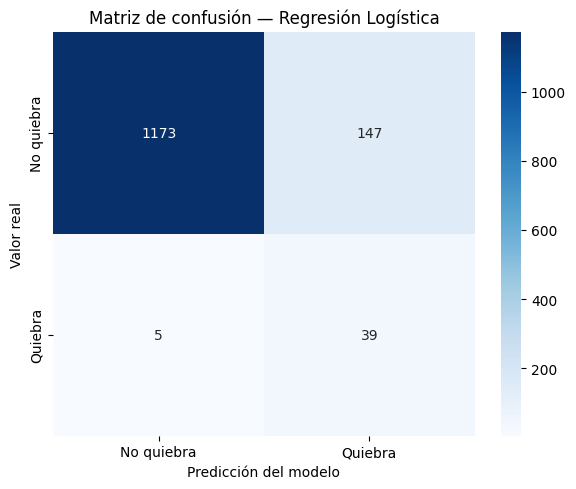

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No quiebra', 'Quiebra'],
            yticklabels=['No quiebra', 'Quiebra'])
plt.xlabel('Predicción del modelo')
plt.ylabel('Valor real')
plt.title('Matriz de confusión — Regresión Logística')
plt.tight_layout()
plt.show()

Como primer modelo de clasificación, se entrenó una Regresión Logística (`max_iter=2000`) utilizando las 5.455 empresas del conjunto de entrenamiento y las variables preprocesadas. El conjunto original contenía 95 variables: 93 numéricas y 2 binarias. Se eliminó la variable constante `Net Income Flag`, se estandarizaron las 93 variables numéricas y se mantuvo `Liability-Assets Flag` sin transformar. Además, se incorporó `class_weight='balanced'` para compensar el desbalance de clases.

En el conjunto de prueba, el modelo obtuvo un AUC-ROC de **0.9486** y un *Average Precision* de **0.4270**, ampliamente superior al valor de referencia aleatorio (≈ **0.0323**). Para la clase `Quiebra`, alcanzó un *recall* de **0.89**, identificando correctamente 39 de las 44 empresas quebradas. Sin embargo, registró una precisión de **0.20**, debido a los **153 falsos positivos**, y un F1-score de **0.33**. Estos resultados reflejan el equilibrio entre recall y precisión en un contexto de fuerte desbalance de clases: priorizar la detección de quiebras reales genera un número considerable de falsas alarmas.

### 2.3 Curva ROC

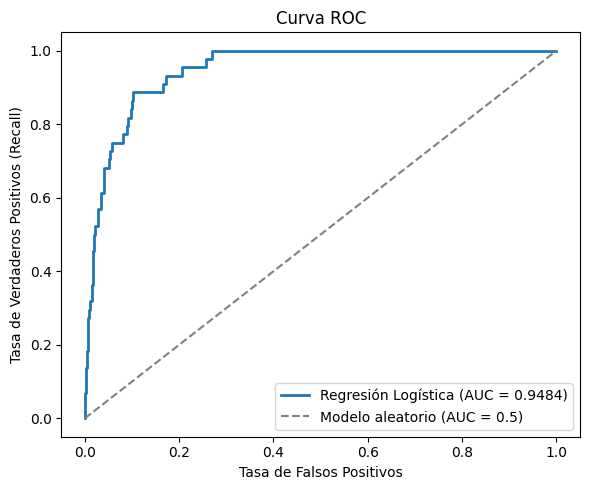

In [11]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, umbrales = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Regresión Logística (AUC = {auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Modelo aleatorio (AUC = 0.5)')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.title('Curva ROC')
plt.legend()
plt.tight_layout()
plt.show()

### 2.4 Curva Precision-Recall

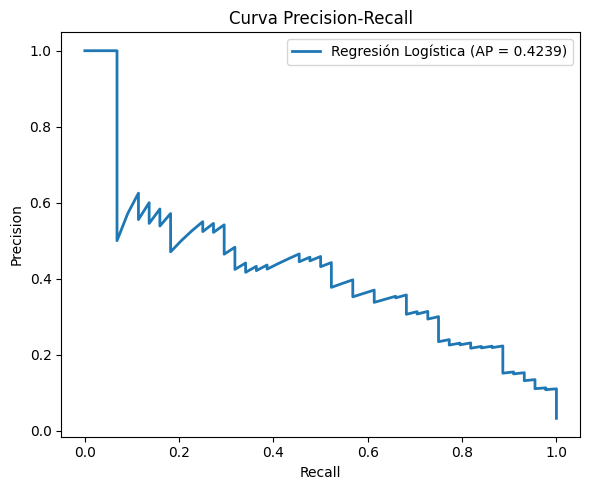

In [12]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, umbrales_pr = precision_recall_curve(y_test, y_pred_proba)
ap = average_precision_score(y_test, y_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'Regresión Logística (AP = {ap:.4f})', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend()
plt.tight_layout()
plt.show()

Las curvas de evaluación permiten complementar y matizar los resultados numéricos previamente reportados. La curva ROC (AUC = 0.9486) evidencia una capacidad discriminativa adecuada del modelo para distinguir entre empresas solventes y empresas en riesgo de quiebra. No obstante, la curva Precision-Recall (AP = 0.4270) ofrece una evaluación más estricta y representativa del desempeño sobre la clase minoritaria: dado el fuerte desbalance presente en los datos (aproximadamente 30 empresas solventes por cada caso de quiebra), la métrica AUC-ROC tiende a sobreestimar el desempeño del modelo, mientras que el área bajo la curva Precision-Recall refleja de manera más fiel la dificultad inherente a la detección de la clase de interés sin incurrir en un número excesivo de falsos positivos.

Es importante señalar que el valor de referencia del *Average Precision* no corresponde a 0, sino a la proporción de la clase positiva en el conjunto de datos (3.23% en este caso). Bajo esta consideración, el AP obtenido (0.4270) representa un desempeño considerablemente superior al de un clasificador aleatorio (AP ≈ 0.0323), aunque continúa evidenciando margen de mejora en la capacidad del modelo para priorizar correctamente los casos de mayor riesgo.

### 2.5 Coeficientes del modelo

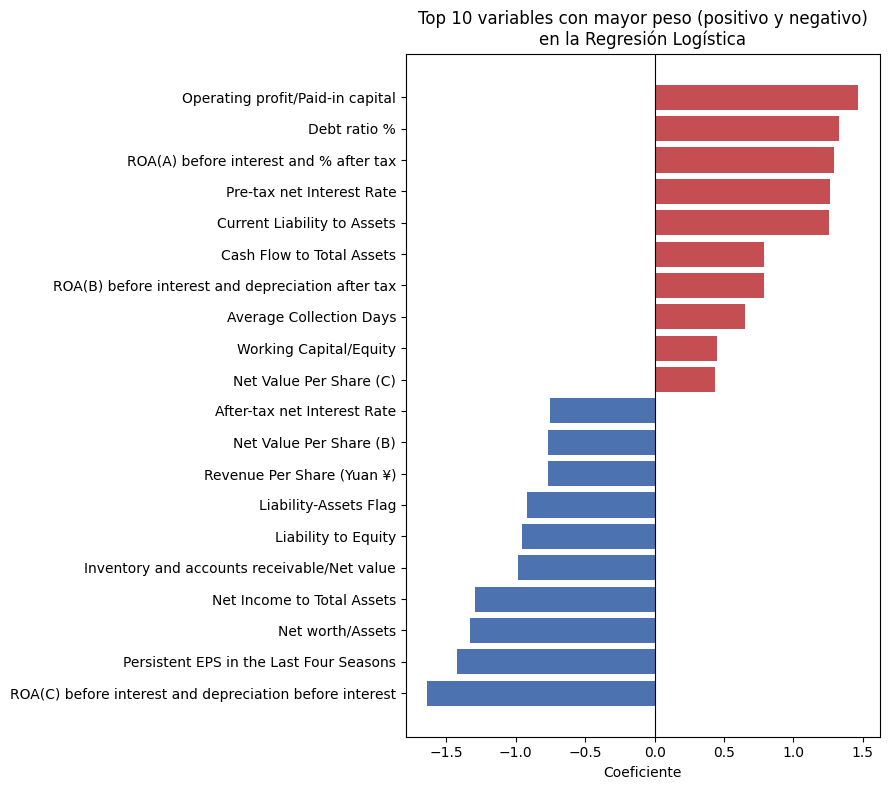

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

coeficientes = pd.Series(log_base.coef_[0], index=X_train_prep.columns).sort_values()


top_10 = pd.concat([coeficientes.head(10), coeficientes.tail(10)])

plt.figure(figsize=(9, 8))
colores = ['#4C72B0' if v < 0 else '#C44E52' for v in top_10.values]
plt.barh(top_10.index, top_10.values, color=colores)
plt.xlabel('Coeficiente')
plt.title('Top 10 variables con mayor peso (positivo y negativo)\nen la Regresión Logística')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

El análisis de los coeficientes del modelo corrobora, desde una perspectiva lineal, los patrones previamente identificados durante el análisis exploratorio de datos mediante correlaciones y la medida de importancia de variables obtenida con [Random Forest](./EDA.ipynb#random-forest). Las variables asociadas a la rentabilidad de la empresa, en particular *Persistent EPS in the Last Four Seasons*, presentan los coeficientes negativos de mayor magnitud, lo cual indica que niveles sostenidos de rentabilidad se asocian con una menor probabilidad de quiebra. En contraste, los coeficientes positivos más elevados corresponden a *Pre-tax net Interest Rate*, *Operating profit/Paid-in capital* y *ROA(A) before interest and % after tax*, seguidos de cerca por *Debt ratio %*, evidenciando que un mayor peso relativo de los gastos financieros y del apalancamiento incrementa la probabilidad estimada de quiebra. Esta convergencia entre los hallazgos del análisis exploratorio y los resultados del modelo predictivo constituye una evidencia adicional de la consistencia y robustez de los patrones financieros identificados a lo largo del presente trabajo.

Resulta pertinente destacar dos hallazgos que enriquecen la interpretación de los coeficientes obtenidos.

En primer lugar, la variable `Liability-Assets Flag` presenta un coeficiente negativo en el modelo (≈ -0.85), resultado que contrasta con lo observado en el análisis bivariado (sección 8.3), donde el grupo con Flag = 1 registró una tasa de quiebra del 60%, frente al 3.2% del grupo con Flag = 0. Esta aparente contradicción constituye un hallazgo de interés metodológico: una relación univariada marcadamente fuerte puede invertirse en un modelo multivariado como consecuencia de la interacción con otras variables incluidas en el modelo, o bien por el tamaño muestral extremadamente reducido del grupo minoritario (n = 5 en el conjunto de entrenamiento), circunstancia ya señalada previamente en este trabajo. Este resultado ilustra la importancia de no extrapolar directamente las relaciones observadas en un análisis exploratorio univariado hacia la interpretación de los coeficientes de un modelo multivariado.

En segundo lugar, la variable `ROA(A) before interest and % after tax` exhibe un coeficiente positivo (1.37) pese a presentar una correlación negativa con la variable objetivo en el análisis exploratorio (r = -0.28). Este comportamiento confirma la advertencia formulada en la sección 1.4 respecto a la multicolinealidad existente entre las distintas versiones de la variable ROA incluidas en el conjunto de datos. La inversión en el signo del coeficiente corresponde precisamente al efecto de inestabilidad que dicha multicolinealidad puede inducir sobre las estimaciones del modelo lineal, validando empíricamente la advertencia anticipada en etapas previas del análisis.

### 2.6 Ajuste del umbral de decisión

Dado el contexto de nuestro dataset, decidimos priorizar los falsos negativos por encima de los
falsos positivos: nuestra situación más grave es no advertir a una empresa que en realidad está
en riesgo de quiebra, y no tanto marcar en alerta a una que en realidad está sana. Sin embargo,
nunca buscamos llevar los falsos negativos a cero, porque eso implicaría sacrificar toda la
precisión del modelo. Por esta razón, decidimos explorar el efecto de mover el umbral de decisión
por debajo de 0.5. *Métrica Referencia:* cuántas de las 44 empresas que sí quebraron detectas.

In [14]:
# Reutilizamos precision, recall, umbrales_pr de la Curva Precision-Recall (sección 2.4) —
# no hay que recalcular nada del modelo, solo elegir un punto distinto de esa curva.

# Elegimos el umbral MÁS ALTO que aún garantice el recall mínimo que queremos.
# ¿Por qué el más alto y no cualquiera? Porque entre varios umbrales que logran el
# mismo recall, el más alto es el que menos sacrifica precisión (menos falsas alarmas).
recall_objetivo = 0.90  # tu prioridad: no dejar pasar quiebras reales

idx_validos = np.where(recall[:-1] >= recall_objetivo)[0]
idx_elegido = idx_validos[np.argmax(umbrales_pr[idx_validos])]
umbral_elegido = umbrales_pr[idx_elegido]

print(f"Umbral elegido: {umbral_elegido:.4f}")
print(f"Recall en ese punto: {recall[idx_elegido]:.4f}")
print(f"Precisión en ese punto: {precision[idx_elegido]:.4f}")

Umbral elegido: 0.3284
Recall en ese punto: 0.9091
Precisión en ese punto: 0.1544


In [15]:
# Comparamos las dos matrices de confusión: umbral por defecto vs. umbral ajustado
from sklearn.metrics import confusion_matrix, classification_report

y_pred_05 = (y_pred_proba >= 0.5).astype(int)              # lo que ya tenías (default)
y_pred_ajustado = (y_pred_proba >= umbral_elegido).astype(int)  # con el nuevo umbral

print("--- Umbral 0.5 (default) ---")
print(confusion_matrix(y_test, y_pred_05))

print("\n--- Umbral ajustado ---")
print(confusion_matrix(y_test, y_pred_ajustado))
print(classification_report(y_test, y_pred_ajustado, target_names=['No quiebra', 'Quiebra']))

--- Umbral 0.5 (default) ---
[[1173  147]
 [   5   39]]

--- Umbral ajustado ---
[[1101  219]
 [   4   40]]
              precision    recall  f1-score   support

  No quiebra       1.00      0.83      0.91      1320
     Quiebra       0.15      0.91      0.26        44

    accuracy                           0.84      1364
   macro avg       0.58      0.87      0.59      1364
weighted avg       0.97      0.84      0.89      1364



## 3. PIPELINE

In [22]:
# ============================================================
# GRIDSEARCH CON PIPELINE (sin fuga de datos entre folds)
# class_weight='balanced' fijo (no se busca en la grilla, ver celda 1.4)
# ============================================================
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix,
                              roc_auc_score, average_precision_score, f1_score)
import pandas as pd

# --- Winsorizer como transformador de sklearn ---
# Los límites de percentil 1/99 se recalculan en cada fold del GridSearch,
# usando SOLO los datos de entrenamiento de ese fold (evita fuga de información).
class Winsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.01, upper=0.99, exclude=None):
        self.lower = lower
        self.upper = upper
        self.exclude = exclude or []

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.cols_ = [c for c in X.columns if c not in self.exclude]
        self.limits_ = {c: (X[c].quantile(self.lower), X[c].quantile(self.upper)) for c in self.cols_}
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for c in self.cols_:
            li, ls = self.limits_[c]
            X[c] = X[c].clip(li, ls)
        return X


# --- Preprocesamiento: mismo esquema híbrido de la celda 1.3 ---
# Las 5 variables con escala de origen inconsistente van con StandardScaler;
# el resto (robustas ante los outliers "normales" ya documentados en el EDA)
# van con RobustScaler. Liability-Assets Flag pasa sin tocar.
cols_patologicas = [
    'Interest-bearing debt interest rate',
    'Fixed Assets Turnover Frequency',
    'Inventory/Current Liability',
    'Long-term Liability to Current Assets',
    'Current Asset Turnover Rate',
]
cols_robust = [c for c in X_train.columns
               if c not in ['Liability-Assets Flag', 'Net Income Flag'] + cols_patologicas]

preprocessor = ColumnTransformer(
    [('robust', RobustScaler(), cols_robust),
     ('standard', StandardScaler(), cols_patologicas)],
    remainder='passthrough')  # deja pasar Liability-Assets Flag sin tocar

pipe = Pipeline([
    ('winsor', Winsorizer(lower=0.01, upper=0.99, exclude=['Liability-Assets Flag', 'Net Income Flag'])),
    ('preprocess', preprocessor),
    ('clf', LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced'))
])

# --- Grilla de hiperparámetros de Regresión Logística ---
# class_weight NO está en la grilla: queda fijo en 'balanced' (definido arriba en el pipe).
# l2: la más común. l1: puede "apagar" variables (útil dada la multicolinealidad
# que detectaste entre versiones de ROA). elasticnet: combina ambas.
param_grid = [
    {'clf__penalty': ['l2'], 'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
     'clf__solver': ['lbfgs']},
    {'clf__penalty': ['l1'], 'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
     'clf__solver': ['liblinear']},
    {'clf__penalty': ['elasticnet'], 'clf__C': [0.01, 0.1, 1, 10],
     'clf__l1_ratio': [0.2, 0.5, 0.8],
     'clf__solver': ['saga']},
]

# StratifiedKFold: cada fold mantiene ~3.23% de quiebras, igual que tu train/test split.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipe, param_grid,
    scoring='average_precision',  # más exigente que accuracy/F1 bajo desbalance fuerte
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# Se entrena con X_train "crudo" (sin winsorizar/escalar manualmente antes) —
# el pipeline hace todo eso internamente, fold por fold.
grid.fit(X_train.drop(columns=['Net Income Flag']), y_train)

print("Mejores parámetros:", grid.best_params_)
print(f"Mejor Average Precision en validación cruzada: {grid.best_score_:.4f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits


c:\Users\laure\anaconda3\envs\MlP\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\laure\anaconda3\envs\MlP\Lib\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Mejores parámetros: {'clf__C': 0.1, 'clf__penalty': 'l1', 'clf__solver': 'liblinear'}
Mejor Average Precision en validación cruzada: 0.3967


In [23]:
# ============================================================
# EVALUAR EL MEJOR MODELO EN TEST
# ============================================================
X_test_clean = X_test.drop(columns=['Net Income Flag'])
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test_clean)
y_proba = best_model.predict_proba(X_test_clean)[:, 1]

print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"Average Precision: {average_precision_score(y_test, y_proba):.4f}")
print(f"F1-score (Quiebra): {f1_score(y_test, y_pred):.4f}")
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))

AUC-ROC: 0.9494
Average Precision: 0.4225
F1-score (Quiebra): 0.3264

Matriz de confusión:
 [[1164  156]
 [   5   39]]


**Modelo de referencia adoptado:** se adopta la regresión logística manual (`log_base`, C=1.0,
penalty='l2') con el umbral de decisión ajustado a 0.328 como modelo de referencia para esta
etapa. Esta configuración es la que mejor refleja la prioridad de negocio establecida en la
sección 2.6: minimizar los falsos negativos, detectando 40 de las 44 empresas en quiebra del
conjunto de prueba (recall = 0.909), frente a 39/44 del modelo con umbral por defecto. El modelo
ajustado por GridSearch (`C=0.1`, `penalty='l1'`) no se adopta como referencia: con el mismo
umbral de 0.5, iguala el recall del modelo manual pero con una precisión ligeramente inferior
(147 vs. 156 falsos positivos para el mismo acierto), por lo que no ofrece una ventaja real sobre
la configuración por defecto para este problema.

## CONCLUSIONES DEL PREPROCESAMIENTO

El presente capítulo abordó la etapa de preprocesamiento y el entrenamiento de un primer modelo de clasificación —Regresión Logística con `class_weight='balanced'`— sobre el conjunto de datos *Company Bankruptcy Prediction*. El pipeline de preprocesamiento implementado consistió en el winsorizing por percentiles fijos, la eliminación de la variable constante `Net Income Flag`, y la estandarización de las variables numéricas mediante un esquema híbrido (`RobustScaler` para las variables cuyos outliers son financieramente plausibles, y `StandardScaler` para las 5 variables cuya escala de origen resultó inconsistente incluso después del winsorizing), ajustado exclusivamente sobre `train` y aplicado posteriormente a `test`.

Como métricas independientes del umbral de decisión, el modelo obtuvo un AUC-ROC de 0.9494 y un *Average Precision* de 0.4270 — este último considerablemente superior al de un clasificador aleatorio (≈0.0323, correspondiente a la proporción de la clase positiva), aunque continúa reflejando que la detección de empresas en riesgo sin incurrir en un número elevado de falsos positivos es un desafío considerable dado el fuerte desbalance de clases.

Dado que la prioridad de negocio establecida (Sección 2.6) es minimizar los falsos negativos, se adoptó como modelo de referencia la Regresión Logística manual con el umbral de decisión ajustado a 0.328 (en vez del umbral por defecto de 0.5), tras confirmar que un modelo alternativo optimizado mediante GridSearch (`C=0.1`, `penalty='l1'`) no ofrecía una ventaja real sobre esta configuración. Con este umbral, el modelo detecta 40 de las 44 empresas que efectivamente quebraron en el conjunto de prueba (*recall* = 0.909), frente a 39/44 con el umbral por defecto, a costa de una precisión de 0.15 y 219 falsos positivos (frente a 147 con el umbral por defecto). Este resultado refleja explícitamente la prioridad de negocio adoptada: se sacrifica precisión de forma deliberada para minimizar los falsos negativos.

El análisis de los coeficientes del modelo permitió, adicionalmente, corroborar desde una perspectiva lineal los patrones financieros identificados previamente mediante correlaciones y la medida de importancia de variables obtenida con Random Forest durante el EDA: las variables asociadas a la rentabilidad de la empresa —en particular, `Persistent EPS in the Last Four Seasons`— presentan los coeficientes negativos de mayor magnitud, mientras que las variables relacionadas con el nivel de endeudamiento —encabezadas por `Pre-tax net Interest Rate`, `Operating profit/Paid-in capital` y `Debt ratio %`— exhiben los coeficientes positivos más elevados. Esta convergencia entre los hallazgos exploratorios y los resultados del modelo predictivo constituye evidencia adicional de la robustez de los patrones identificados a lo largo de este trabajo.

### Problemas identificados para la siguiente etapa

De acuerdo con los resultados obtenidos, se identifican las siguientes limitaciones y oportunidades de mejora para las etapas posteriores del proyecto:

1. **La precisión sigue siendo baja incluso tras ajustar el umbral.** El ajuste del umbral de decisión (Sección 2.6) permitió mejorar el *recall* de 0.89 a 0.909, pero a costa de aumentar los falsos positivos de 147 a 219. Esto confirma que el umbral por sí solo no resuelve el problema de fondo: el modelo lineal tiene una capacidad limitada para separar ambas clases con mayor precisión. Se recomienda explorar modelos no lineales (Random Forest, Gradient Boosting) que puedan capturar relaciones más complejas entre las variables.

2. **La regularización explorada mediante GridSearch no mejoró el desempeño.** Se probaron penalizaciones L1, L2 y Elastic Net (Sección 2.7) mediante validación cruzada de 5 folds, optimizando *Average Precision*. Ninguna configuración superó de forma consistente a la regresión logística manual con parámetros por defecto, lo que sugiere que el desempeño del modelo lineal está limitado por la naturaleza de los datos (multicolinealidad, desbalance) más que por una mala elección de hiperparámetros.

3. **Persistencia del desbalance de clases.** Si bien la ponderación de clases (`class_weight='balanced'`) y el ajuste de umbral permitieron mejorar sustancialmente el *recall*, técnicas adicionales de remuestreo —como SMOTE u otras variantes de sobremuestreo sintético— podrían aportar mejoras complementarias, y deberían explorarse en la siguiente fase del proyecto.

4. **Multicolinealidad no resuelta.** Tal como se documentó durante el EDA, diversas variables de rentabilidad (distintas versiones de ROA) presentan correlaciones cercanas a 0.9–1.0 entre sí. Aunque el GridSearch probó regularización L1 (capaz de eliminar variables redundantes), el modelo adoptado como referencia no incorpora este tratamiento, por lo que la multicolinealidad sigue presente en los coeficientes reportados.

5. **Validación limitada a una única partición de prueba.** Si bien el GridSearch empleó validación cruzada estratificada de 5 folds para seleccionar hiperparámetros, la evaluación final del modelo de referencia se realizó sobre una única partición de `test`. Repetir esta evaluación con distintas semillas o mediante validación cruzada completa permitiría obtener estimaciones más robustas del desempeño reportado.